In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
zip_path = "/content/drive/MyDrive/breastcancerdetectml/ultrasounddataset.zip"
extract_path = "/content/ultrasounddataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Unzipped successfully!")

Unzipped successfully!


In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Dropout
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
train_path = "/content/ultrasounddataset/ultrasound breast classification/train"
val_path   = "/content/ultrasounddataset/ultrasound breast classification/val"

categories = ["benign", "malignant"]

IMG_SIZE = 128
LIMIT = 5000   # prevents RAM crash

In [6]:
data = []
labels = []

count = 0

for category in categories:
    path = os.path.join(train_path, category)
    label = categories.index(category)

    for img in os.listdir(path):

        if count >= LIMIT:
            break

        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)

        if image is None:
            continue   # skip bad images

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0

        data.append(image)
        labels.append(label)

        count += 1

print("Training images loaded:", len(data))

Training images loaded: 5000


In [7]:
data = np.array(data)
labels = np.array(labels)

print(data.shape)
print(labels.shape)

(5000, 128, 128, 3)
(5000,)


In [8]:
val_data = []
val_labels = []

for category in categories:
    path = os.path.join(val_path, category)
    label = categories.index(category)

    for img in os.listdir(path):

        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0

        val_data.append(image)
        val_labels.append(label)

print("Validation images loaded:", len(val_data))

Validation images loaded: 900


In [9]:
val_data = np.array(val_data)
val_labels = np.array(val_labels)

print("Val shape:", val_data.shape)
print("Val labels shape:", val_labels.shape)

Val shape: (900, 128, 128, 3)
Val labels shape: (900,)


In [10]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [23]:
history = model.fit(
    data,
    labels,
    epochs=20,
    batch_size=16,
    validation_data=(val_data, val_labels),
    callbacks=[early_stop]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8758 - loss: 0.2772 - val_accuracy: 0.7333 - val_loss: 0.4800
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9008 - loss: 0.2255 - val_accuracy: 0.6489 - val_loss: 0.6352
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9278 - loss: 0.1877 - val_accuracy: 0.7011 - val_loss: 0.4903
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9474 - loss: 0.1416 - val_accuracy: 0.7400 - val_loss: 0.4800
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9646 - loss: 0.1104 - val_accuracy: 0.8467 - val_loss: 0.3548
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9724 - loss: 0.0874 - val_accuracy: 0.7811 - val_loss: 0.5444
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9778 - loss: 0.0694 - val_accuracy: 0.8678 - val_loss: 0.3054
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9826 - loss: 0.0576 - val_accu

In [34]:
loss, accuracy = model.evaluate(val_data, val_labels)

print("Final Validation Loss:", loss)
print("Final Validation Accuracy:", accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8678 - loss: 0.3054
Final Validation Loss: 0.3053668439388275
Final Validation Accuracy: 0.8677777647972107


In [36]:
y_probs = model.predict(val_data).ravel()

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [37]:
y_pred_default = (y_probs > 0.5).astype(int)

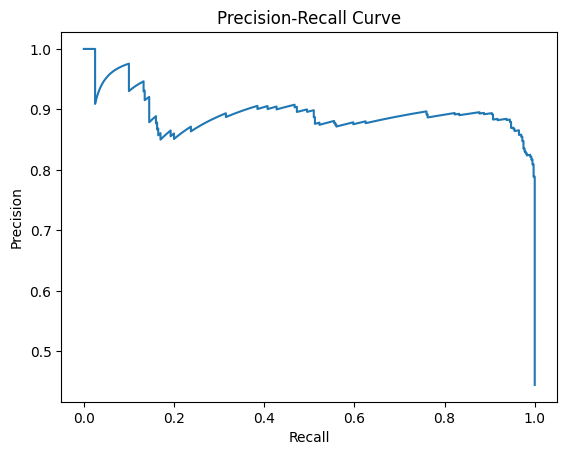

In [38]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(val_labels, y_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [39]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.28328282
Best F1 Score: 0.9130434732665874


In [40]:
y_pred_best = (y_probs > best_threshold).astype(int)

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_labels, y_pred_best)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[450  50]
 [ 23 377]]


In [42]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, y_pred_best))

              precision    recall  f1-score   support

           0       0.95      0.90      0.92       500
           1       0.88      0.94      0.91       400

    accuracy                           0.92       900
   macro avg       0.92      0.92      0.92       900
weighted avg       0.92      0.92      0.92       900



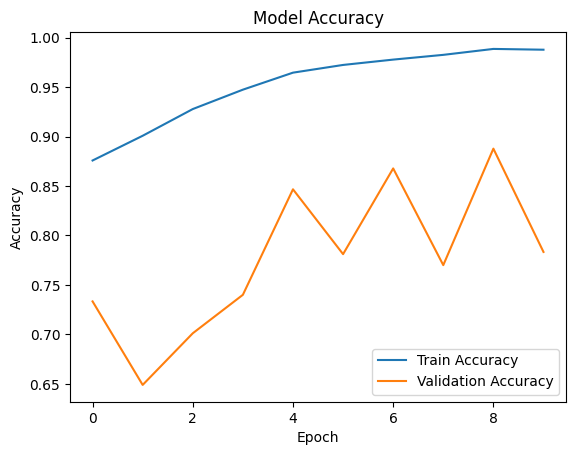

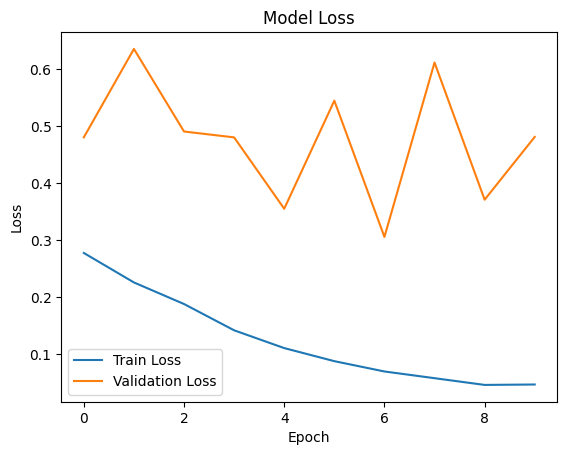

In [44]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("accuracy_curve.png")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("loss_curve.png")
plt.show()

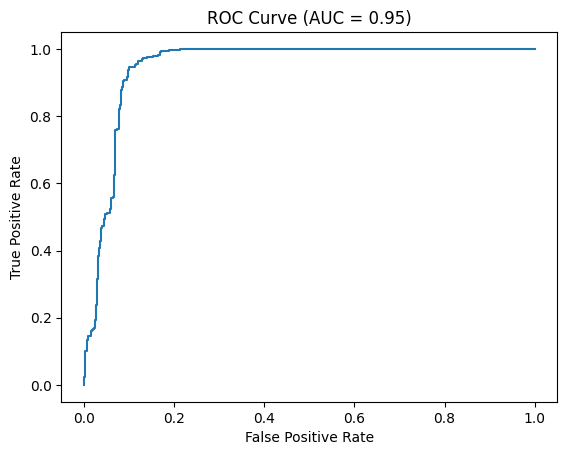

In [32]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(val_labels, y_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [52]:
model.save("/content/drive/MyDrive/breastcancerdetectml/breast_cancer_cnn_final.keras")


In [53]:
plt.savefig("/content/drive/MyDrive/breastcancerdetectml/accuracy.png")
plt.savefig("/content/drive/MyDrive/breastcancerdetectml/loss.png")
plt.savefig("/content/drive/MyDrive/breastcancerdetectml/pr_curve.png")

<Figure size 640x480 with 0 Axes>